In [ ]:
import os
import pandas as pd
from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline
from PIL import Image
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
from diffusers.optimization import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm

torch.set_float32_matmul_precision('high')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
# Upload zip to Colab
from google.colab import drive
import shutil

drive.mount('/content/drive')
shutil.copytree( # Move to Local memory
    "/content/drive/MyDrive/skin_data",
    "/content/skin_data"
)

Mounted at /content/drive


'/content/skin_data'

In [ ]:
DATA_DIR = "/content/skin_data"
OUTPUT_DIR = "./ddpm_224_model_v2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_TIMESTEPS = 1000
MIXED_PRECISION = DEVICE == "cuda"
BATCH_SIZE = 32
SEED = 42
GRAD_ACCUM_STEPS = 1
LR = 1e-4
NUM_EPOCHS = 50
SAVE_IMAGE_EVERY = 10 # save image every X epoch
SAVE_MODEL_EVERY = 10 # save model every X epoch

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
def get_df(split):
    """Construct a dataframe of the path of each image and its label."""
    data = []
    for label in ['benign', 'malignant']:
        path = os.path.join(DATA_DIR, split, label)
        if os.path.exists(path):
            for file in os.listdir(path):
                data.append({'path': os.path.join(path, file), 'label': label})
    return pd.DataFrame(data)

df_train_full = get_df('train')
df_train_malignant = df_train_full[df_train_full['label'] == 'malignant']

In [ ]:
print(df_train_malignant.head())
print(df_train_full['label'].value_counts())

                                             path      label
1440  /content/skin_data/train/malignant/1101.jpg  malignant
1441   /content/skin_data/train/malignant/605.jpg  malignant
1442   /content/skin_data/train/malignant/233.jpg  malignant
1443   /content/skin_data/train/malignant/974.jpg  malignant
1444   /content/skin_data/train/malignant/449.jpg  malignant
label
benign       1440
malignant    1197
Name: count, dtype: int64


In [ ]:
class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.label_map = {'benign': 0.0, 'malignant': 1.0}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[self.dataframe.iloc[idx]['label']]

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor([label], dtype=torch.float32)

baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Failsafe
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalize the pixel values to have a mean of 0 and std of 1 (helps CNNs learn faster)
])

dataset = ISICDataset(df_train_malignant, transform=baseline_transforms)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)


In [ ]:
model = UNet2DModel(
    sample_size=224,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128,256,256,256), # Adjust for detail
    down_block_types=(
        "DownBlock2D", # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D", # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
).to(DEVICE)
model = torch.compile(model)

noise_scheduler = DDPMScheduler(num_train_timesteps=NUM_TIMESTEPS)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
num_update_steps_per_epoch = max(1, len(dataloader) // GRAD_ACCUM_STEPS)
max_train_steps = NUM_EPOCHS * num_update_steps_per_epoch

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=max(100, max_train_steps // 20),
    num_training_steps=max_train_steps,
)

In [ ]:
global_step = 0
epoch_losses= []

for epoch in range(NUM_EPOCHS):
    model.train()
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    optimizer.zero_grad(set_to_none=True)
    running_loss = 0

    for step, (clean_images, _) in enumerate(progress_bar):
        clean_images = clean_images.to(DEVICE)

        # Sample random noise
        noise = torch.randn_like(clean_images)

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (clean_images.shape[0],),
            device=DEVICE
        ).long()

        # Add noise to the clean images according to the timestep
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            noise_pred = model(noisy_images, timesteps).sample
            loss = F.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        lr_scheduler.step()
        global_step += 1

        progress_bar.set_postfix(loss=float(loss.item() * GRAD_ACCUM_STEPS))
        running_loss += loss.item()

    epoch_losses.append(running_loss / len(dataloader))

    # ----------------------------
    # Save sample images during training
    # ----------------------------
    if (epoch + 1) % SAVE_IMAGE_EVERY == 0:
        model.eval()
        pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler).to(DEVICE)
        generator = torch.Generator(device=DEVICE).manual_seed(SEED)

        images = pipeline(
            batch_size=8,
            generator=generator,
            num_inference_steps=NUM_TIMESTEPS,
            output_type="pil"
        ).images

        sample_dir = Path(OUTPUT_DIR) / "samples"
        sample_dir.mkdir(parents=True, exist_ok=True)
        for i, img in enumerate(images):
            img.save(sample_dir / f"epoch_{epoch+1:03d}_sample_{i}.png")

    # ----------------------------
    # Save model checkpoint
    # ----------------------------
    if (epoch + 1) % SAVE_MODEL_EVERY == 0:
        checkpoint_dir = Path(OUTPUT_DIR) / f"checkpoint-{epoch+1}"
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

        pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
        pipeline.save_pretrained(checkpoint_dir)

# Final save
final_pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
final_pipeline.save_pretrained(OUTPUT_DIR)

print(f"Training complete. Model saved to: {OUTPUT_DIR}")

Epoch 1/50:   0%|          | 0/38 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/variables/functions.py:2056: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
  torch._dynamo.utils.warn_once(msg)


Epoch 2/50:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/38 [00:00<?, ?it/s]

...

Epoch 48/50:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Training complete. Model saved to: ./ddpm_224_model_v2


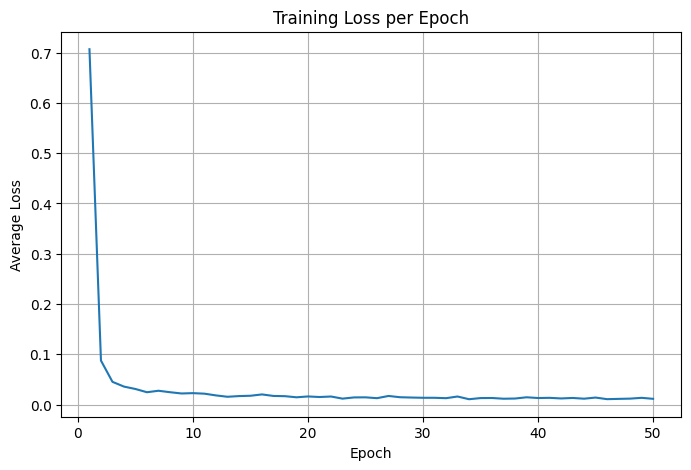

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)
plt.show()

In [ ]:
!cp -r ./ddpm_224_model_v2 /content/drive/MyDrive/